# Estatística 1 - Aula prática 4_2 em Python

## UNIDADE 4: Testes de hipóteses paramétricos e intervalos de confiança

### Seção 4.2: Unpaired test or two-sample test

By Jose P. Leitão

### Teste de duas amostras independentes - Unpaired Z test

In [147]:
# Carregando as bibliotecas
%matplotlib inline

# Importar bibliotecas
import numpy as np

import pandas as pd

from scipy.stats import norm, t, shapiro, f, ttest_ind

from statsmodels.stats.weightstats import ztest, zconfint

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

### Carregando a base de dados "qi_unpaired", trata-se uma amostra com dois grupos, garotos e garotas, e que contem o "QI" de cada individuo, vamos ver a base de dados

In [148]:
df = pd.read_csv('qi_unpaired.csv')
df.head()

,group,qi
0,boy,79
1,boy,118
2,boy,99
3,boy,117
4,boy,98


### Vamos fazer checagens preliminares para verificar as exigencias do teste: Amostras independentes, normalidade e homogeneidade das variancias entre grupos

### Premissa 1: As duas amostras são independentes?
- Sim, pois os grupos de garotos e garotas não estão relacionados.
- Não se trata de uma amostra ou grupos emparelhados.

### Premissa 2: Os dados de cada amostra/grupo possuem distribuição normal?

Vamos usar o teste de normalidade Shapiro-Wilk com o seguinte teste de hipóteses:

- H0: os dados são normalmente distribuidos 
- Ha: os dados não são normalmente distribuidos

In [149]:
# Primeiro vamos fazer o teste de normalidade Shapiro-Wilk para o
# "QI" dos garotos
x = df.loc[df["group"] == 'boy', ['qi']]
stat, p = shapiro(x)
print(f"p-value : {p:.4f}")  
# p-value > 0.05 (ou seja, 0.3253), logo o grupo possui
# distribuicao normal

p-value : 0.3253


In [150]:
# Agora vamos fazer o teste de normalidade Shapiro-Wilk para o 
# "QI" das garotas
x = df.loc[df["group"] == 'girl', ['qi']]
stat, p = shapiro(x)
print(f"p-value : {p:.4f}")     
# p-value>0.05 (ou seja, 0.2594), logo o grupo possui 
# distribuicao normal


p-value : 0.2594


Pelos resultados dos testes, os dois valores de p-value são maiores do que o nivel de significancia 0.05, o que implica que a distribuicao dos dados nao é significativamente diferente da distribuição normal. 

Em outras palavras, podemos assumir que os dois grupos possuem distribuição normal.

### Premissa 3. As duas populações/amostras/grupos possuem homogeneidade das variâncias?

O teste de hipóteses é:

- H0: As variâncias são estatisticamente iguais(homogêneas)
- HA: As variâncias não são estatisticamente iguais(homogêneas)

In [ ]:
import numpy as np
from scipy import stats

def f_test(sample1, sample2, alpha=0.05):
    """
    Perform a two-tailed F-test to compare variances of two samples.
    
    Parameters:
        sample1 (list/array): First dataset
        sample2 (list/array): Second dataset
        alpha (float): Significance level (default 0.05)
    
    Returns:
        dict: F-statistic, p-value, and test conclusion
    """
    # Convert to numpy arrays
    x = np.array(sample1, dtype=float)
    y = np.array(sample2, dtype=float)

    # Validate input
    if x.size < 2 or y.size < 2:
        raise ValueError("Both samples must have at least two values.")
    if np.any(np.isnan(x)) or np.any(np.isnan(y)):
        raise ValueError("Samples must not contain NaN values.")

    # Calculate variances
    var_x = np.var(x, ddof=1)  # sample variance
    var_y = np.var(y, ddof=1)

    # F-statistic (larger variance / smaller variance)
    if var_x > var_y:
        f_stat = var_x / var_y
        dfn, dfd = len(x) - 1, len(y) - 1
    else:
        f_stat = var_y / var_x
        dfn, dfd = len(y) - 1, len(x) - 1

    # Two-tailed p-value
    p_value = 2 * min(
        stats.f.cdf(f_stat, dfn, dfd),
        1 - stats.f.cdf(f_stat, dfn, dfd)
    )

    # Conclusion
    reject_null = p_value < alpha

    return {
        "F-statistic": f_stat,
        "p-value": p_value,
        "Reject Null (variances equal)": reject_null
    }


In [152]:
# Usaremos o teste F para testar a homogeneidade nas variancias. 
x1 = df.loc[df["group"] == 'boy', ['qi']].to_numpy()
x2 = df.loc[df["group"] == 'girl', ['qi']].to_numpy()

result = f_test(x1, x2, alpha=0.05)

print("F-statistic:", result["F-statistic"])
print("p-value:", result["p-value"])
print("Reject Null Hypothesis:", result["Reject Null (variances equal)"])

F-statistic: 1.0004377433237304
p-value: 0.9980993801742957
Reject Null Hypothesis: False


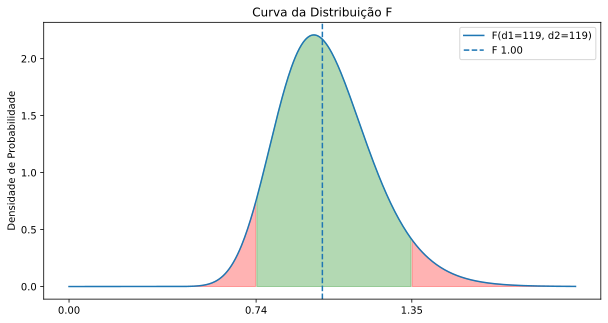

In [153]:
F = result["F-statistic"]

# graus de liberdade
d1 = 119   # grau de liberdade do numerador
d2 = 119   # grau de liberdade do denominador

# significância
alfa = 0.05 # 5%

# intervalo de valores
x = np.linspace(0, 2, 500)

# função densidade da distribuição F
y = f.pdf(x, d1, d2)

# valores críticos
q2 = f.ppf(1-alfa, d1, d2)
q1 = 1/q2

# plot
plt.figure(figsize=(10,5))
plt.plot(x, y, label=f'F(d1={d1}, d2={d2})')
plt.fill_between(x, y, where=((x < q1) | (x > q2)), alpha= 0.3, color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), alpha=0.3, color='green')

plt.axvline(F,linestyle="--", label=f"F {F:.2f}")

plt.title('Curva da Distribuição F')
plt.xticks([0, q1, q2])
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.ylabel('Densidade de Probabilidade')
plt.legend()


plt.show()


O teste de F tem valor critico entre 0.74 e 1.35 (região de não rejeição de H0), os valores acima de 1.35 e abaixo de 0.74 estão na região de rejeição de H0 (area vermelha do grafico). O valor da estatistica F calculada é 1.00043. Como esse valor se encontra na região de não rejeição de H0, entao não rejeitamos a hipótese de que as variâncias são estatisticamente iguais.

Observe que se os individuos não forem independentes trata-se de uma amostra emparelhada e devemos utilizar o teste para esse tipo de amostra. Se os dados não forem normalmente distribuidos, e as variâncias nao forem homogêneas é recomendável usar o teste de duas amostras independentes não paramétrico.

Feitas essas checagens preliminares, como os grupos são independentes, normalmente distribuidos e possuem variância homogênea, agora podemos fazer o teste Z para duas amostras/grupos e responder o seguinte:

### Pergunta: Existe alguma diferenca significativa entre o "qi" das garotas e dos garotos?

Para responder executamos o seguinte teste de hipoteses:
- H0: A diferença verdadeira entre as médias dos "qi"s dos grupos (garotos e garotas) é igual a zero, ou seja, as médias são estatisticamente iguais
- HA: A diferença verdadeira entre as medias dos "qi"s dos grupos (garotos e garotas) não é igual a zero, ou seja, as médias são estatisticamente diferentes

### Fazendo o teste!

In [154]:
# Vamos ver os desvios padrões dos grupos e as suas médias
x1 = df.loc[df["group"] == 'boy', ['qi']].to_numpy()
x2 = df.loc[df["group"] == 'girl',['qi']].to_numpy()
std_boy = np.std(x1)
std_girl = np.std(x2)
media_boy = np.mean(x1)
media_girl = np.mean(x2)
n1, n2 = len(x1), len(x2)

In [155]:
# Agora vamos fazer o teste de Z para amostras ou grupos 
# independentes 
z_stat, p_value = ztest(x1, x2, alternative='two-sided')
z = z_stat[0]
print(f"Z-stat : {z:.3f}")
print(f"p-value : {p_value[0]:.5f}")

Z-stat : -2.347
p-value : 0.01891


In [156]:
# Calcular o intervalo de confiança

ic1, ic2 = zconfint(x1=x1, x2=x2, value=0, ddof=1)

print(f"Os intervalos de confiança são : {ic1[0]:.4f}, {ic2[0]:.4f}")


Os intervalos de confiança são : -8.4409, -0.7591


In [157]:
# As médias das amostras
print(f"As médias das amostras são : {media_boy:.3f}, {media_girl:.3f}")

As médias das amostras são : 105.575, 110.175


No resultado:
- "Z" eh o valor estatistico do teste (Z = -2.348);  
- "p-value" eh o nivel de significancia do teste Z (valor de p = 0.01891); 
- O intervalo de confianca da diferenca entre as medias a 95% de confianca se situa entre -8.4408 e -0.7591;
- "sample estimates" é o valor da media de cada grupo da amostra (media dos garotos = 105.575, e a media das garotas = 110.175).

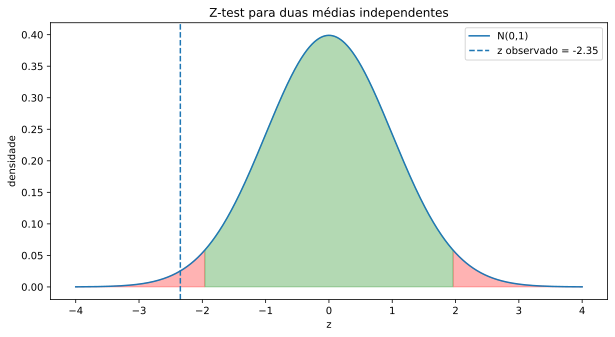

In [158]:
# Vamos construir o gráfico da distribuição Z

# significância
alfa = 0.05 # 5%

# valores para plot
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(10,5))
plt.plot(x, y, label="N(0,1)")

# limites críticos
z_crit = norm.ppf(1 - alfa/2)

# regiões críticas
# Rejeição de H0
plt.fill_between(x, y, where=((x < -z_crit) | (x > z_crit)), alpha=0.3, color='red')

# Não Rejeição de H0
plt.fill_between(x, y, where=((x >= -z_crit) & (x <= z_crit) ), alpha=0.3, color='green')

# linha do z observado
plt.axvline(z, linestyle="--", label=f"z observado = {z:.2f}")

plt.title("Z-test para duas médias independentes")
plt.xlabel("z")
plt.ylabel("densidade")
plt.legend()

plt.show()


Os valores tabelados/criticos da distribuição Z são -1.96 e 1.96 (área de não rejeição de H0), com 95% de confiança ou 5% de significância. Os valores acima de 1.96 e abaixo de -1.96 são as regiões de rejeição de H0 (área verde do gráfico). Como o valor Z calculado é -2.348, é menor que -1.96, portanto ele se encontra na região de rejeição de H0.

Sendo assim, rejeitamos a hipótese (H0) de que as médias sejam estatisticamente iguais, ou seja, o "qi" médio dos garotos é estatisticamente diferente do "qi" médio das garotas.

Outra forma de interpretar:

- O valor de p do teste é 0.01887, que é menor que o nível de significância 0,05 (5% de significância ou 95% de confiança). 
- Esse p-value se situa na área de rejeição de H0, logo rejeita-se H0. Conclui-se que o "qi" médio dos garotos é estatisticamente diferente do "qi" médio das garotas.

Portanto, como as médias são estatisticamente diferentes e em termos absolutos/nominais o "qi" médio das garotas é maior que a média dos garotos, então as garotas possuem efetivamente "qi" superior.


### Vamos confirmar o resultado com o teste de Welch

In [159]:
result = ttest_ind(x1, x2, equal_var=False)

print(result)

TtestResult(statistic=array([-2.34735383]), pvalue=array([0.01972755]), df=array([237.9999886]))


O teste de Welch confirmou o que o teste de Z apresentou

In [160]:
# Então, a média do "qi" das garotas é 110,175 e dos garotos é 105,575
# Se dividirmos um pelo outro temos:
print(f"{(110.175/105.575)-1:.2%}")
# O "qi" das garotas eh 4,36% superior ao "qi" dos garotos

4.36%


### Teste de duas amostras independentes - Unpaired t test

In [161]:
# Vamos utilizar a base de dados "mw_weight.RData"
# Carregando a base de dados
df = pd.read_csv('mw_weight.csv')

Trata-se de uma amostra com dois grupos, homens e mulheres e que contem o peso de cada individuo, vamos ver a base de dados

In [162]:
df.describe(include='all')

,group,weight
count,18,18.000000
unique,2,NaN
top,Woman,NaN
freq,9,NaN
mean,NaN,60.544444
std,NaN,15.209912
min,NaN,21.800000
25%,NaN,51.600000
50%,NaN,62.900000
75%,NaN,67.675000


Vamos fazer checagens preliminares para verificar as exigencias anteriores para a aplicacao do teste de comparacao das medias:
- Amostras independentes, normalidade e homogeneidade das variancias 

Premissa 1: Os dois grupos sao independentes?
- Sim, pois os grupos de homens e mulheres nao estao relacionados.
- Nao se trata de uma amostra ou grupos emparelhados.

Premissa 2: Os dados de cada grupo segue uma distribuicao normal?

Vamos usar o teste de normalidade Shapiro-Wilk com as seguintes hipoteses:

- H0: os dados sao normalmente distribuidos 
- Ha: os dados nao sao normalmente distribuidos

Primeiro vamos fazer o teste de normalidade Shapiro-Wilk para os pesos masculinos

In [163]:
x = df.loc[df["group"] == 'Man', ['weight']]
stat, p = shapiro(x)
print(f"p-value : {p:.4f}")  

p-value : 0.1066


p-value>0.05 (0.1066), logo o grupo possui distribuicao normal

Agora vamos fazer o teste de normalidade Shapiro-Wilk para os pesos femininos

In [164]:
x = df.loc[df["group"] == 'Woman', ['weight']]
stat, p = shapiro(x)
print(f"p-value : {p:.4f}")  

p-value : 0.6101


p-value>0.05 (0.6101), logo o grupo possui distribuicao normal

Pelos resultados dos testes, os dois valores de p-value sao maiores do que o nivel de significancia 0.05, o que implica que a distribuicao dos dados nao eh estatisticamente diferente da distribuicao normal. 

Em outras palavras, podemos assumir que os grupos possuem distribuicao normal.

Premissa 3: As duas populacoes tem as variancias estatisticamente iguais?

O teste de hipoteses eh o seguinte:

- H0: As variancias sao estatisticamente iguais(homogeneas)
- HA: As variancias nao sao estatisticamente iguais(homogeneas)

Usaremos o teste F para testar a homogeneidade das variancias. 

In [165]:
# Usaremos o teste F para testar a homogeneidade nas variancias. 
x1 = df.loc[df["group"] == 'Man', ['weight']].to_numpy()
x2 = df.loc[df["group"] == 'Woman', ['weight']].to_numpy()

result = f_test(x1, x2, alpha=0.05)

print("F-statistic:", result["F-statistic"])
print("p-value:", result["p-value"])
print("Reject Null Hypothesis:", result["Reject Null (variances equal)"])

F-statistic: 2.767478313081674
p-value: 0.17135955229379674
Reject Null Hypothesis: False


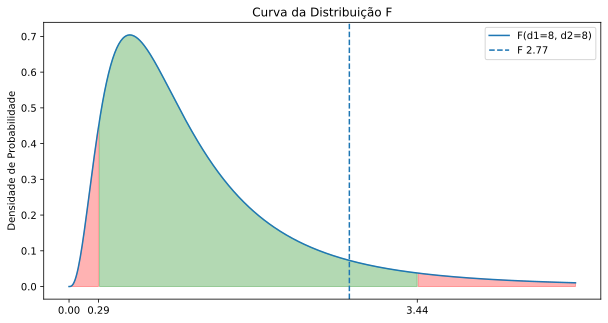

In [166]:
F = result["F-statistic"]

# graus de liberdade
d1 = 8   # grau de liberdade do numerador
d2 = 8   # grau de liberdade do denominador

# significância
alfa = 0.05 # 5%

# intervalo de valores
x = np.linspace(0, 5, 500)

# função densidade da distribuição F
y = f.pdf(x, d1, d2)

# valores críticos
q2 = f.ppf(1-alfa, d1, d2)
q1 = 1/q2

# plot
plt.figure(figsize=(10,5))
plt.plot(x, y, label=f'F(d1={d1}, d2={d2})')
plt.fill_between(x, y, where=((x < q1) | (x > q2)), alpha= 0.3, color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), alpha=0.3, color='green')

plt.axvline(F,linestyle="--", label=f"F {F:.2f}")

plt.title('Curva da Distribuição F')
plt.xticks([0, q1, q2])
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.ylabel('Densidade de Probabilidade')
plt.legend()


plt.show()


O valor calculado do teste eh 2.77, e a area de nao rejeicao de H0 (variancias iguais) esta entre 0,29 e 3,44. 
Portanto, podemos considerar que as variancias sao estatisticamente iguais.

Entao depois das verificacoes preliminares temos que:
- As amostras/grupos sao independentes; as amostras ou grupos sao normalmente distribuidos; e as amostras ou grupos tem variancia homogenea.

Observe que se os individuos nao forem independentes, devemos utilizar um teste para dados pareados. Se os dados nao forem normalmente distribuidos, e as variancias nao forem homogeneas eh recomendavel usar o teste de duas amostras independentes nao parametrico.

Feitas essas verificacoes preliminares tem-se a seguinte pergunta: Existe alguma diferenca significativa entre os pesos das mulheres e dos homens?

Para responder executamos o seguinte teste de hipoteses:
- H0: A verdadeira diferenca das medias entre os grupos homens e mulheres eh igual a zero, ou seja, as medias sao estatisticamente iguais
- HA: A verdadeira diferenca das medias entre os grupos homens e mulheres nao eh igual a zero, ou seja, as medias sao estatisticamente diferentes

In [167]:
# Fazendo o teste:

x1 = df.loc[df["group"] == 'Man', ['weight']].to_numpy()
x2 = df.loc[df["group"] == 'Woman', ['weight']].to_numpy()

result = ttest_ind(x1, x2, equal_var=True) # considera que ambas as amostras apresentam mesma variancia
t_stastistic = result.statistic[0]

ci_inf, ci_sup = result.confidence_interval(0.95)

In [168]:
print(f"t = {t_stastistic:.4f}")
print(f"p-value = {result.pvalue[0]:.5f}")
print(f"{result.df[0]:.4f}")
print(f"os intervalos de confiança são {ci_inf[0]:.6f} e {ci_sup[0]:.6f}")
print(f"As médias das amostras são {np.mean(x1):.2f} e {np.mean(x2):.2f}")

t = 2.7842
p-value = 0.01327
16.0000
os intervalos de confiança são 4.029759 e 29.748019
As médias das amostras são 68.99 e 52.10


In [169]:
# No resultado:
# a) "t" eh o valor estatistico do teste (t = 2.7842);  
# b) "p-value" eh o nivel de significancia do teste t (valor de
#    p = 0.01327); 
# c) O intervalo de confianca da diferenca entre as medias a 95%
#    de confianca se situa entre 4.029759 e 29.748019;
# d) "sample estimates" eh o valor da media de cada grupo da 
#    amostra (media dos homens = 68.99, e a media das mulheres
#    = 52.10).

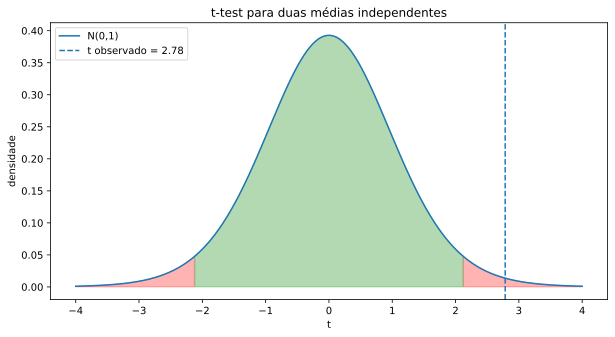

In [ ]:
# Vamos construir o gráfico da distribuição t de Student

# significância
alfa = 0.05 # 5%

# valores para plot
x = np.linspace(-4, 4, 1000)
y = t.pdf(x, df=16)

plt.figure(figsize=(10,5))
plt.plot(x, y, label="N(0,1)")

# limites críticos
t_crit = t.ppf(1 - alfa/2, df=16)

# regiões críticas
# Rejeição de H0
plt.fill_between(x, y, where=((x < -t_crit) | (x > t_crit)), alpha=0.3, color='red')

# Não Rejeição de H0
plt.fill_between(x, y, where=((x >= -t_crit) & (x <= t_crit) ), alpha=0.3, color='green')

# linha do z observado
plt.axvline(t_stastistic, linestyle="--", label=f"t observado = {t_stastistic:.2f}")

plt.title("t-test para duas médias independentes")
plt.xlabel("t")
plt.ylabel("densidade")
plt.legend()

plt.show()

A estatistica t calculada eh 2,7842 e se encontra na regiao de rejeicao de H0, portanto, conclui-se que as medias sao estatisticamente diferentes.

Outra forma de interpretar:
- O valor de p do teste eh 0.01327, que eh menor que o nivel de significancia 0,05 (5% de signific�ncia ou 95% de confianca). Esse p-value se situa na area de rejeicao de H0, logo rejeita-se H0. Conclui-se que o peso medio dos homens eh estatisticamente diferente do peso medio das mulheres.

In [171]:
result = ttest_ind(x1, x2, equal_var=False)
print(result)

TtestResult(statistic=array([2.78423537]), pvalue=array([0.01538424]), df=array([13.11375207]))


In [172]:
# O teste de Welch confirmou o resultado

In [173]:
# Portanto, se dividirmos as medias temos:
print(f"{(68.99/52.10)-1:.2%}")
# o peso medio dos homens eh 32,42% superior ao peso medio das
# mulheres

32.42%
